In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.svm import LinearSVC

load_dotenv()

DATASET_PATH = os.getenv("DATASET_PATH")
IMAGE_ROOT = os.path.join(DATASET_PATH, "image_features", "image_features")
DATASET_DIR = os.path.join(DATASET_PATH)

In [2]:
os.chdir(DATASET_PATH)

with open('train.json', 'r', encoding='utf-8') as f:
    train_data = json.load(f)	
with open('val.json', 'r', encoding='utf-8') as f:
    val_data = json.load(f)

print(f"Train data length: {len(train_data)}")
print(f"Val data length: {len(val_data)}")


combined_data = {**train_data, **val_data}

print(f"Combined data length: {len(combined_data)}")

with open('new_test.json', 'r', encoding='utf-8') as f:
    test_data = json.load(f)

print(f"New test data length: {len(test_data)}")

Train data length: 1983
Val data length: 283
Combined data length: 2266
New test data length: 378


Device: cuda
Classes (5): [np.str_('Brain Metastase Tumour'), np.str_('Glioma'), np.str_('Meningioma'), np.str_('Pineal tumour and Choroid plexus tumour'), np.str_('Tumors of the sellar region')]

Loading radiomics CSVs...
Radiomics train: (1085, 20)  val: (153, 20)
Radiomics usable  train: (1085, 20)  val: (153, 20)

── Image MLP: ax_t1 ──
   train=1983  val=283
  [ax_t1] Epoch  10 | val acc 0.505  (best 0.597 @ ep 4)
  [ax_t1] Epoch  20 | val acc 0.576  (best 0.597 @ ep 4)
  [ax_t1] Epoch  30 | val acc 0.583  (best 0.597 @ ep 4)
  [ax_t1] Epoch  40 | val acc 0.569  (best 0.597 @ ep 4)
  [ax_t1] Epoch  50 | val acc 0.580  (best 0.604 @ ep 44)
  [ax_t1] Best model saved → checkpoints\ax_t1_best.pt  (epoch 44, val acc 0.604)

── Image MLP: ax_t1c ──
   train=1899  val=270
  [ax_t1c] Epoch  10 | val acc 0.552  (best 0.574 @ ep 2)
  [ax_t1c] Epoch  20 | val acc 0.533  (best 0.600 @ ep 14)
  [ax_t1c] Epoch  30 | val acc 0.578  (best 0.604 @ ep 28)
  [ax_t1c] Epoch  40 | val acc 0.581  (bes

c:\Users\Charles Poon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Charles Poon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Charles Poon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

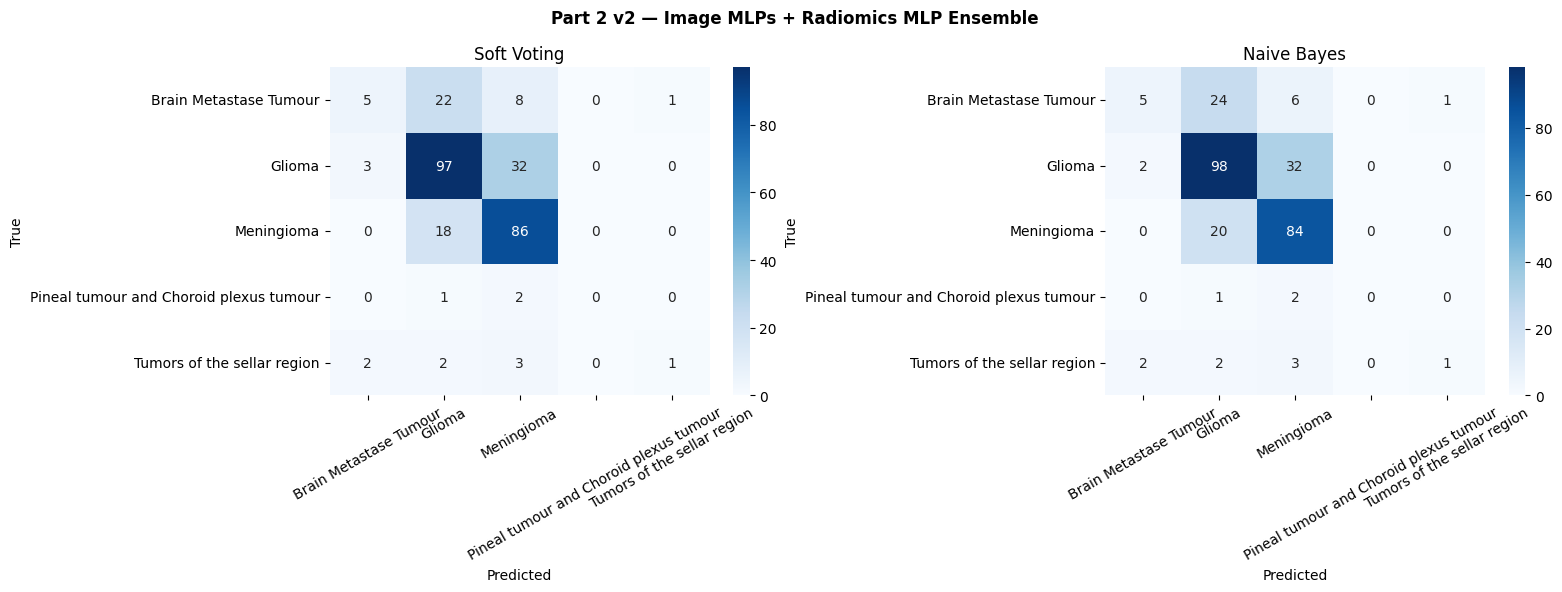

In [3]:
"""
Part 2 (v2) — Per-modality Image MLPs + Radiomics MLP + Ensemble
Changes vs original:
  1. Best-model checkpointing in train_mlp() — saves the epoch with highest val acc.
  2. Per-class probability DataFrame — scores_df built during ensemble_predict().
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import copy  # ← needed for best-model checkpointing

# ── Config ─────────────────────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODALITIES  = ["ax_t1", "ax_t1c", "ax_t2", "ax_t2f"]
FEATURE_DIM = 2048
EPOCHS      = 50
BATCH_SIZE  = 32
LR          = 1e-3
DROPOUT     = 0.4
CKPT_DIR    = "checkpoints"   # ← folder where .pt files are saved
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Device: {DEVICE}")

# ── Label encoder ──────────────────────────────────────────────────────────────
all_labels = [r["Overall_class"] for r in train_data.values()]
le = LabelEncoder().fit(all_labels)
CLASSES, N_CLASSES = list(le.classes_), len(le.classes_)
print(f"Classes ({N_CLASSES}): {CLASSES}")

# ══════════════════════════════════════════════════════════════════════════════
# A) RADIOMICS DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
RAD_FEATURES = [
    "rad_firstorder_Mean", "rad_firstorder_Entropy",
    "rad_firstorder_90Percentile", "rad_glcm_Contrast", "rad_glcm_JointEntropy"
]
RAD_DIR = os.path.join(DATASET_DIR, "radiomics_info")

def load_radiomics_split(split: str) -> pd.DataFrame:
    dfs = []
    for mod in MODALITIES:
        path = os.path.join(RAD_DIR, split, f"{mod}_radiomics_{split}.csv")
        df = pd.read_csv(path)
        df = df[["case_id"] + RAD_FEATURES].rename(
            columns={f: f"{mod}_{f}" for f in RAD_FEATURES}
        )
        dfs.append(df)
    merged = dfs[0]
    for df in dfs[1:]:
        merged = merged.merge(df, on="case_id", how="inner")
    return merged.dropna().set_index("case_id")

print("\nLoading radiomics CSVs...")
rad_train_df = load_radiomics_split("train")
rad_val_df   = load_radiomics_split("val")
print(f"Radiomics train: {rad_train_df.shape}  val: {rad_val_df.shape}")

RAD_COLS = rad_train_df.columns.tolist()

def rad_xy(rad_df: pd.DataFrame, split_dict: dict):
    rows, labels, ids = [], [], []
    for case_id_int in rad_df.index:
        key = str(case_id_int)
        if key not in split_dict:
            continue
        rows.append(rad_df.loc[case_id_int].values.astype(np.float32))
        labels.append(split_dict[key]["Overall_class"])
        ids.append(key)
    return np.vstack(rows), np.array(labels), ids

X_rad_train, y_rad_train_str, rad_train_ids = rad_xy(rad_train_df, train_data)
X_rad_val,   y_rad_val_str,   rad_val_ids   = rad_xy(rad_val_df,   val_data)
print(f"Radiomics usable  train: {X_rad_train.shape}  val: {X_rad_val.shape}")

rad_scaler       = StandardScaler().fit(X_rad_train)
X_rad_train_sc   = rad_scaler.transform(X_rad_train).astype(np.float32)
X_rad_val_sc     = rad_scaler.transform(X_rad_val).astype(np.float32)

# ══════════════════════════════════════════════════════════════════════════════
# B) IMAGE DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
def load_modality_xy(split_dict: dict, modality: str):
    X, y, ids = [], [], []
    for case_id, record in split_dict.items():
        npy_path = os.path.join(IMAGE_ROOT, str(case_id), modality, "image.npy")
        if not os.path.exists(npy_path):
            continue
        X.append(np.load(npy_path).astype(np.float32))
        ids.append(case_id)
        y.append(record["Overall_class"])
    return np.vstack(X), np.array(y), ids

# ══════════════════════════════════════════════════════════════════════════════
# C) MODELS
# ══════════════════════════════════════════════════════════════════════════════
class ImageMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(FEATURE_DIM, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(512, 128),         nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(128, N_CLASSES)
        )
    def forward(self, x): return self.net(x)

class RadiomicsMLP(nn.Module):
    def __init__(self, in_dim=20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(64, 32),     nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(32, N_CLASSES)
        )
    def forward(self, x): return self.net(x)

# ══════════════════════════════════════════════════════════════════════════════
# CHANGE 1 — best-model checkpointing
# ══════════════════════════════════════════════════════════════════════════════
def train_mlp(model, X_tr, y_tr_str, X_vl, y_vl_str, name):
    y_tr = le.transform(y_tr_str)
    y_vl = le.transform(y_vl_str)

    tr_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=True)
    vl_loader = DataLoader(
        TensorDataset(torch.tensor(X_vl), torch.tensor(y_vl, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=False)

    model.to(DEVICE)
    opt  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    crit = nn.CrossEntropyLoss()

    # ── tracking variables ────────────────────────────────────────────────────
    best_val_acc   = 0.0
    best_state     = None   # deepcopy of state_dict at best epoch
    best_epoch     = 0
    # ─────────────────────────────────────────────────────────────────────────

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        sch.step()

        # ── evaluate every epoch for checkpointing (print every 10) ──────────
        model.eval()
        vc, vt = 0, 0
        with torch.no_grad():
            for xb, yb in vl_loader:
                out = model(xb.to(DEVICE))
                vc += (out.argmax(1) == yb.to(DEVICE)).sum().item()
                vt += len(yb)
        val_acc = vc / vt

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = copy.deepcopy(model.state_dict())
            best_epoch   = epoch

        if epoch % 10 == 0:
            print(f"  [{name}] Epoch {epoch:3d} | val acc {val_acc:.3f}"
                  f"  (best {best_val_acc:.3f} @ ep {best_epoch})")
        # ─────────────────────────────────────────────────────────────────────

    # ── load best weights back into the model ────────────────────────────────
    model.load_state_dict(best_state)

    # ── persist to disk ───────────────────────────────────────────────────────
    ckpt_path = os.path.join(CKPT_DIR, f"{name}_best.pt")
    torch.save({"epoch": best_epoch, "val_acc": best_val_acc,
                "state_dict": best_state}, ckpt_path)
    print(f"  [{name}] Best model saved → {ckpt_path}  "
          f"(epoch {best_epoch}, val acc {best_val_acc:.3f})")
    # ─────────────────────────────────────────────────────────────────────────

    return model

# ══════════════════════════════════════════════════════════════════════════════
# D) TRAIN ALL 5 MLPs
# ══════════════════════════════════════════════════════════════════════════════
models = {}

for mod in MODALITIES:
    print(f"\n── Image MLP: {mod} ──")
    X_tr, y_tr, _ = load_modality_xy(train_data, mod)
    X_vl, y_vl, _ = load_modality_xy(val_data,   mod)
    print(f"   train={len(X_tr)}  val={len(X_vl)}")
    models[mod] = train_mlp(ImageMLP(), X_tr, y_tr, X_vl, y_vl, mod)

print(f"\n── Radiomics MLP (20-d) ──")
print(f"   train={len(X_rad_train_sc)}  val={len(X_rad_val_sc)}")
models["radiomics"] = train_mlp(
    RadiomicsMLP(), X_rad_train_sc, y_rad_train_str,
                    X_rad_val_sc,   y_rad_val_str, "radiomics"
)

# ══════════════════════════════════════════════════════════════════════════════
# E) ENSEMBLE INFERENCE
# ══════════════════════════════════════════════════════════════════════════════
rad_val_lookup = {
    str(cid): X_rad_val_sc[i]
    for i, cid in enumerate(rad_val_ids)
}

def get_probs(model, vec: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        x = torch.tensor(vec[None], dtype=torch.float32).to(DEVICE)
        return F.softmax(model(x), dim=1).cpu().numpy()[0]

ALL_VOTERS = MODALITIES + ["radiomics"]   # fixed voter order for the DataFrame

# ══════════════════════════════════════════════════════════════════════════════
# CHANGE 2 — per-class probability DataFrame
# ══════════════════════════════════════════════════════════════════════════════
def ensemble_predict(split_dict: dict):
    pred_vote, pred_nb, true_labels = [], [], []

    # column names: "<voter>__<class>"  e.g. "ax_t1__MEL", "radiomics__NV"
    score_cols = [f"{v}__{c}" for v in ALL_VOTERS for c in CLASSES]
    score_rows = []   # one dict per case
    case_ids   = []

    for case_id, record in split_dict.items():
        prob_list  = []
        voter_probs = {}   # voter_name → prob array (or None if missing)

        # image voters
        for mod in MODALITIES:
            npy_path = os.path.join(IMAGE_ROOT, str(case_id), mod, "image.npy")
            if os.path.exists(npy_path):
                vec  = np.load(npy_path).astype(np.float32)
                p    = get_probs(models[mod], vec)
                prob_list.append(p)
                voter_probs[mod] = p
            else:
                voter_probs[mod] = None

        # radiomics voter
        if case_id in rad_val_lookup:
            p = get_probs(models["radiomics"], rad_val_lookup[case_id])
            prob_list.append(p)
            voter_probs["radiomics"] = p
        else:
            voter_probs["radiomics"] = None

        if not prob_list:
            continue

        probs = np.stack(prob_list)
        pred_vote.append(probs.mean(axis=0).argmax())
        pred_nb.append(np.log(probs + 1e-9).sum(axis=0).argmax())
        true_labels.append(le.transform([record["Overall_class"]])[0])

        # ── build score row ───────────────────────────────────────────────────
        row = {"case_id": case_id,
               "true_label": record["Overall_class"]}
        for v in ALL_VOTERS:
            p = voter_probs[v]
            for i, cls in enumerate(CLASSES):
                row[f"{v}__{cls}"] = float(p[i]) if p is not None else float("nan")
        score_rows.append(row)
        case_ids.append(case_id)
        # ─────────────────────────────────────────────────────────────────────

    scores_df = pd.DataFrame(score_rows).set_index("case_id")
    return (np.array(true_labels), np.array(pred_vote), np.array(pred_nb),
            scores_df)

print("\nRunning ensemble on validation set...")
true, pred_vote, pred_nb, scores_df = ensemble_predict(val_data)

print(f"\nscores_df shape: {scores_df.shape}")
print(scores_df.head(3).to_string())

# ══════════════════════════════════════════════════════════════════════════════
# F) REPORTS
# ══════════════════════════════════════════════════════════════════════════════
for preds, name in [(pred_vote, "Soft Voting (image + radiomics)"),
                    (pred_nb,   "Naive Bayes (image + radiomics)")]:
    print(f"\n{'='*55}")
    print(f"  Part 2 v2 — {name}")
    print("="*55)
    print(classification_report(true, preds, target_names=CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Part 2 v2 — Image MLPs + Radiomics MLP Ensemble", fontweight="bold")

for ax, (preds, name) in zip(axes, [(pred_vote, "Soft Voting"),
                                     (pred_nb,   "Naive Bayes")]):
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [4]:
scores_df

,true_label,ax_t1__Brain Metastase Tumour,ax_t1__Glioma,ax_t1__Meningioma,ax_t1__Pineal tumour and Choroid plexus tumour,ax_t1__Tumors of the sellar region,ax_t1c__Brain Metastase Tumour,ax_t1c__Glioma,ax_t1c__Meningioma,ax_t1c__Pineal tumour and Choroid plexus tumour,...,ax_t2f__Brain Metastase Tumour,ax_t2f__Glioma,ax_t2f__Meningioma,ax_t2f__Pineal tumour and Choroid plexus tumour,ax_t2f__Tumors of the sellar region,radiomics__Brain Metastase Tumour,radiomics__Glioma,radiomics__Meningioma,radiomics__Pineal tumour and Choroid plexus tumour,radiomics__Tumors of the sellar region
case_id,,,,,,,,,,,,,,,,,,,,,
153,Meningioma,0.001535,0.561787,0.436116,0.000473,0.000090,0.000338,0.095966,0.899864,0.000201,...,0.000049,0.037850,0.961939,0.000008,0.000153,NaN,NaN,NaN,NaN,NaN
2555,Meningioma,0.073607,0.922977,0.001216,0.001782,0.000419,0.003077,0.841944,0.128339,0.025081,...,0.000458,0.061409,0.937804,0.000118,0.000212,NaN,NaN,NaN,NaN,NaN
2393,Meningioma,0.000166,0.071221,0.928226,0.000242,0.000145,0.000002,0.011186,0.988808,0.000002,...,0.000104,0.003728,0.995714,0.000107,0.000348,0.188828,0.305086,0.284297,0.087404,0.134386
2086,Meningioma,0.528705,0.467314,0.003375,0.000460,0.000146,0.000923,0.014016,0.984488,0.000398,...,0.004172,0.037695,0.957784,0.000099,0.000250,0.168491,0.456335,0.241565,0.056067,0.077542
2508,Meningioma,0.281588,0.121477,0.510069,0.021229,0.065638,0.002466,0.021615,0.975357,0.000350,...,0.032774,0.911350,0.045848,0.001943,0.008086,0.169885,0.363373,0.308057,0.071158,0.087527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,Tumors of the sellar region,0.002675,0.994539,0.002764,0.000006,0.000015,NaN,NaN,NaN,NaN,...,0.153362,0.602346,0.161325,0.008248,0.074719,NaN,NaN,NaN,NaN,NaN
2020,Tumors of the sellar region,0.007067,0.109120,0.878247,0.004882,0.000685,0.030760,0.034383,0.859719,0.003689,...,0.210876,0.015265,0.770638,0.002358,0.000863,0.138316,0.404658,0.358384,0.047299,0.051342
2931,Pineal tumour and Choroid plexus tumour,0.020105,0.002231,0.977499,0.000044,0.000121,0.074335,0.446697,0.255743,0.033947,...,0.003300,0.001146,0.995335,0.000022,0.000197,0.219503,0.458287,0.203844,0.061005,0.057360


# Clinical


In [5]:
from dotenv import load_dotenv
import os
import json
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

load_dotenv()

DATASET_PATH = os.getenv("DATASET_PATH", "")
os.chdir(DATASET_PATH)
path = DATASET_PATH

# ── Load CSVs ──────────────────────────────────────────────────────────────────
df_train = pd.read_csv(os.path.join(path, "clinical_information", "train_patient_info.csv"))
df_val   = pd.read_csv(os.path.join(path, "clinical_information", "val_patient_info.csv"))

# ── Load JSONs ─────────────────────────────────────────────────────────────────
with open("train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)
with open("val.json", "r", encoding="utf-8") as f:
    val_data = json.load(f)

print(f"Train: {len(train_data)}  Val: {len(val_data)}")

# ── Encode categorical features ────────────────────────────────────────────────
categorical_columns = [
    "Sex", "Tumor Location",
    "Signal Intensity (T1)", "Signal Intensity (T1c)",
    "Signal Intensity (T2)", "Signal Intensity (T2-FLAIR)"
]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore", dtype=int)
encoder.fit(df_train[categorical_columns])

feature_names = encoder.get_feature_names_out(categorical_columns)

def build_feature_df(df_raw, encoded):
    out = pd.DataFrame(encoded, columns=feature_names, index=df_raw.index)
    out.insert(0, "case_id", df_raw["case_id"].values)
    out.insert(1, "age",     df_raw["Age"].values)
    out["age"] = out["age"].fillna(out["age"].median())
    return out

X_train_df = build_feature_df(df_train, encoder.transform(df_train[categorical_columns]))
X_val_df   = build_feature_df(df_val,   encoder.transform(df_val[categorical_columns]))

# ── Attach labels ──────────────────────────────────────────────────────────────
type_mapping_train = {int(k): v["Overall_class"] for k, v in train_data.items()}
type_mapping_val   = {int(k): v["Overall_class"] for k, v in val_data.items()}

X_train_df["Type"] = X_train_df["case_id"].map(type_mapping_train)
X_val_df["Type"]   = X_val_df["case_id"].map(type_mapping_val)

# ── Train on full training set, evaluate on actual val set ────────────────────
X_train = X_train_df.drop(columns=["case_id", "Type"])
y_train = X_train_df["Type"]

X_val   = X_val_df.drop(columns=["case_id", "Type"])
y_val   = X_val_df["Type"]

lr = LogisticRegression(max_iter=2000, solver="lbfgs")
lr.fit(X_train, y_train)

y_pred       = lr.predict(X_val)
y_pred_proba = lr.predict_proba(X_val)   # (n_val, n_classes)

print("Validation accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

# ── Build scores DataFrame ─────────────────────────────────────────────────────
scores_df_lr = pd.DataFrame(
    y_pred_proba,
    columns=[f"clinical_lr__{cls}" for cls in lr.classes_],
    index=X_val_df.index
)
scores_df_lr.insert(0, "case_id",    X_val_df["case_id"].values)
scores_df_lr.insert(1, "true_label", y_val.values)
scores_df_lr = scores_df_lr.set_index("case_id")

print(f"\nscores_df_lr shape: {scores_df_lr.shape}")
print(scores_df_lr.head(3).to_string())

Train: 1983  Val: 283
Validation accuracy: 0.7561837455830389
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour       0.53      0.25      0.34        36
                                 Glioma       0.72      0.88      0.79       132
                             Meningioma       0.83      0.82      0.83       104
Pineal tumour and Choroid plexus tumour       1.00      0.33      0.50         3
            Tumors of the sellar region       1.00      0.38      0.55         8

                               accuracy                           0.76       283
                              macro avg       0.82      0.53      0.60       283
                           weighted avg       0.75      0.76      0.74       283


scores_df_lr shape: (283, 6)
         true_label  clinical_lr__Brain Metastase Tumour  clinical_lr__Glioma  clinical_lr__Meningioma  clinical_lr__Pineal tumour and Choroid plexus tumour  clinical_lr__Tumor

In [6]:
scores_df.head()

,true_label,ax_t1__Brain Metastase Tumour,ax_t1__Glioma,ax_t1__Meningioma,ax_t1__Pineal tumour and Choroid plexus tumour,ax_t1__Tumors of the sellar region,ax_t1c__Brain Metastase Tumour,ax_t1c__Glioma,ax_t1c__Meningioma,ax_t1c__Pineal tumour and Choroid plexus tumour,...,ax_t2f__Brain Metastase Tumour,ax_t2f__Glioma,ax_t2f__Meningioma,ax_t2f__Pineal tumour and Choroid plexus tumour,ax_t2f__Tumors of the sellar region,radiomics__Brain Metastase Tumour,radiomics__Glioma,radiomics__Meningioma,radiomics__Pineal tumour and Choroid plexus tumour,radiomics__Tumors of the sellar region
case_id,,,,,,,,,,,,,,,,,,,,,
153,Meningioma,0.001535,0.561787,0.436116,0.000473,0.000090,0.000338,0.095966,0.899864,0.000201,...,0.000049,0.037850,0.961939,0.000008,0.000153,NaN,NaN,NaN,NaN,NaN
2555,Meningioma,0.073607,0.922977,0.001216,0.001782,0.000419,0.003077,0.841944,0.128339,0.025081,...,0.000458,0.061409,0.937804,0.000118,0.000212,NaN,NaN,NaN,NaN,NaN
2393,Meningioma,0.000166,0.071221,0.928226,0.000242,0.000145,0.000002,0.011186,0.988808,0.000002,...,0.000104,0.003728,0.995714,0.000107,0.000348,0.188828,0.305086,0.284297,0.087404,0.134386
2086,Meningioma,0.528705,0.467314,0.003375,0.000460,0.000146,0.000923,0.014016,0.984488,0.000398,...,0.004172,0.037695,0.957784,0.000099,0.000250,0.168491,0.456335,0.241565,0.056067,0.077542
2508,Meningioma,0.281588,0.121477,0.510069,0.021229,0.065638,0.002466,0.021615,0.975357,0.000350,...,0.032774,0.911350,0.045848,0.001943,0.008086,0.169885,0.363373,0.308057,0.071158,0.087527


In [7]:
print(scores_df_lr.isna().sum().sum())
scores_df_lr.head()

0


,true_label,clinical_lr__Brain Metastase Tumour,clinical_lr__Glioma,clinical_lr__Meningioma,clinical_lr__Pineal tumour and Choroid plexus tumour,clinical_lr__Tumors of the sellar region
case_id,,,,,,
153,Meningioma,0.027760,0.408768,0.554386,0.003440,0.005647
2555,Meningioma,0.164716,0.400583,0.405291,0.013160,0.016250
2393,Meningioma,0.034671,0.053123,0.901363,0.006951,0.003893
2086,Meningioma,0.095358,0.801868,0.093053,0.003694,0.006027
2508,Meningioma,0.051185,0.096698,0.769649,0.016531,0.065937


In [15]:
print("=== Basic Info ===")
print(f"scores_df shape: {scores_df.shape}")
print(f"scores_df_lr shape: {scores_df_lr.shape}")
print(f"\nscores_df columns: {scores_df.columns.tolist()}")
print(f"scores_df_lr columns: {scores_df_lr.columns.tolist()}")

print("\n=== Case ID Info ===")
print(f"'case_id' in scores_df: {'case_id' in scores_df.columns}")
print(f"'case_id' in scores_df_lr: {'case_id' in scores_df_lr.columns}")

if 'case_id' in scores_df.columns:
    print(f"\nscores_df case_id dtype: {scores_df['case_id'].dtype}")
    print(f"scores_df case_id first 5: {scores_df['case_id'].head().tolist()}")
    print(f"scores_df case_id unique count: {scores_df['case_id'].nunique()}")
    
if 'case_id' in scores_df_lr.columns:
    print(f"\nscores_df_lr case_id dtype: {scores_df_lr['case_id'].dtype}")
    print(f"scores_df_lr case_id first 5: {scores_df_lr['case_id'].head().tolist()}")
    print(f"scores_df_lr case_id unique count: {scores_df_lr['case_id'].nunique()}")

if 'case_id' in scores_df.columns and 'case_id' in scores_df_lr.columns:
    print("\n=== Matching Analysis ===")
    set1 = set(scores_df['case_id'])
    set2 = set(scores_df_lr['case_id'])
    
    print(f"Common case_ids: {len(set1 & set2)}")
    print(f"Only in scores_df: {len(set1 - set2)}")
    print(f"Only in scores_df_lr: {len(set2 - set1)}")
    
    if len(set1 - set2) > 0:
        print(f"\nSample case_ids only in scores_df: {list(set1 - set2)[:5]}")
    if len(set2 - set1) > 0:
        print(f"Sample case_ids only in scores_df_lr: {list(set2 - set1)[:5]}")

print("\n=== Duplicate Check ===")
if 'case_id' in scores_df.columns:
    print(f"scores_df duplicate case_ids: {scores_df['case_id'].duplicated().sum()}")
if 'case_id' in scores_df_lr.columns:
    print(f"scores_df_lr duplicate case_ids: {scores_df_lr['case_id'].duplicated().sum()}")

print("\n=== NaN Check ===")
print(f"scores_df total NaN: {scores_df.isna().sum().sum()}")
print(f"scores_df_lr total NaN: {scores_df_lr.isna().sum().sum()}")

print(f"\nscores_df NaN per column:\n{scores_df.isna().sum()}")
print(f"\nscores_df_lr NaN per column:\n{scores_df_lr.isna().sum()}")

print("\n=== Index Info ===")
print(f"scores_df index: {scores_df.index.name}, unique: {scores_df.index.is_unique}")
print(f"scores_df_lr index: {scores_df_lr.index.name}, unique: {scores_df_lr.index.is_unique}")

print("\n=== First 3 rows ===")
print("scores_df:")
print(scores_df.head(3))
print("\nscores_df_lr:")
print(scores_df_lr.head(3))


=== Basic Info ===
scores_df shape: (283, 26)
scores_df_lr shape: (283, 6)

scores_df columns: ['true_label', 'ax_t1__Brain Metastase Tumour', 'ax_t1__Glioma', 'ax_t1__Meningioma', 'ax_t1__Pineal tumour and Choroid plexus tumour', 'ax_t1__Tumors of the sellar region', 'ax_t1c__Brain Metastase Tumour', 'ax_t1c__Glioma', 'ax_t1c__Meningioma', 'ax_t1c__Pineal tumour and Choroid plexus tumour', 'ax_t1c__Tumors of the sellar region', 'ax_t2__Brain Metastase Tumour', 'ax_t2__Glioma', 'ax_t2__Meningioma', 'ax_t2__Pineal tumour and Choroid plexus tumour', 'ax_t2__Tumors of the sellar region', 'ax_t2f__Brain Metastase Tumour', 'ax_t2f__Glioma', 'ax_t2f__Meningioma', 'ax_t2f__Pineal tumour and Choroid plexus tumour', 'ax_t2f__Tumors of the sellar region', 'radiomics__Brain Metastase Tumour', 'radiomics__Glioma', 'radiomics__Meningioma', 'radiomics__Pineal tumour and Choroid plexus tumour', 'radiomics__Tumors of the sellar region']
scores_df_lr columns: ['true_label', 'clinical_lr__Brain Metastas

In [18]:
# Convert both indexes to string
scores_df.index = scores_df.index.astype(str)
scores_df_lr.index = scores_df_lr.index.astype(str)

# Now join will work
ensemble_scores = scores_df.join(scores_df_lr.drop(columns=['true_label']))
print(f"NaN in ensemble_scores: {ensemble_scores.isna().sum().sum()}")

NaN in ensemble_scores: 955


In [21]:
ensemble_scores.head()

,true_label,ax_t1__Brain Metastase Tumour,ax_t1__Glioma,ax_t1__Meningioma,ax_t1__Pineal tumour and Choroid plexus tumour,ax_t1__Tumors of the sellar region,ax_t1c__Brain Metastase Tumour,ax_t1c__Glioma,ax_t1c__Meningioma,ax_t1c__Pineal tumour and Choroid plexus tumour,...,radiomics__Brain Metastase Tumour,radiomics__Glioma,radiomics__Meningioma,radiomics__Pineal tumour and Choroid plexus tumour,radiomics__Tumors of the sellar region,clinical_lr__Brain Metastase Tumour,clinical_lr__Glioma,clinical_lr__Meningioma,clinical_lr__Pineal tumour and Choroid plexus tumour,clinical_lr__Tumors of the sellar region
case_id,,,,,,,,,,,,,,,,,,,,,
153,Meningioma,0.001535,0.561787,0.436116,0.000473,0.000090,0.000338,0.095966,0.899864,0.000201,...,NaN,NaN,NaN,NaN,NaN,0.027760,0.408768,0.554386,0.003440,0.005647
2555,Meningioma,0.073607,0.922977,0.001216,0.001782,0.000419,0.003077,0.841944,0.128339,0.025081,...,NaN,NaN,NaN,NaN,NaN,0.164716,0.400583,0.405291,0.013160,0.016250
2393,Meningioma,0.000166,0.071221,0.928226,0.000242,0.000145,0.000002,0.011186,0.988808,0.000002,...,0.188828,0.305086,0.284297,0.087404,0.134386,0.034671,0.053123,0.901363,0.006951,0.003893
2086,Meningioma,0.528705,0.467314,0.003375,0.000460,0.000146,0.000923,0.014016,0.984488,0.000398,...,0.168491,0.456335,0.241565,0.056067,0.077542,0.095358,0.801868,0.093053,0.003694,0.006027
2508,Meningioma,0.281588,0.121477,0.510069,0.021229,0.065638,0.002466,0.021615,0.975357,0.000350,...,0.169885,0.363373,0.308057,0.071158,0.087527,0.051185,0.096698,0.769649,0.016531,0.065937


In [28]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# =========================
# CONFIG
# =========================
CLASSES = [
    "Brain Metastase Tumour",
    "Glioma",
    "Meningioma",
    "Pineal tumour and Choroid plexus tumour",
    "Tumors of the sellar region"
]

PREFIXES = ["ax_t1", "ax_t1c", "ax_t2f", "radiomics"]

EPS = 1e-6


# =========================
# HELPERS
# =========================
def extract_probs(df, prefix, classes):
    cols = [f"{prefix}__{c}" for c in classes]
    return df[cols].values


def safe_log(x):
    return np.log(np.clip(x, EPS, 1.0))


def normalize(logits):
    probs = np.exp(logits)
    probs /= probs.sum(axis=1, keepdims=True)
    return probs


# =========================
# 1. ALIGN DATA
# =========================
common_idx = scores_df.index.intersection(scores_df_lr.index)

scores_df = scores_df.loc[common_idx].copy()
scores_df_lr = scores_df_lr.loc[common_idx].copy()

le = LabelEncoder()
y = le.fit_transform(scores_df["true_label"])


# =========================
# 2. CLINICAL MODEL
# =========================
clinical_probs = scores_df_lr[
    [f"clinical_lr__{c}" for c in CLASSES]
].values


# =========================
# 3. AGGREGATE IMAGE MODELS
# =========================
model_probs_list = []
valid_mask_list = []

for prefix in PREFIXES:
    probs = extract_probs(scores_df, prefix, CLASSES)

    valid_mask = ~np.isnan(probs).any(axis=1)
    probs = np.nan_to_num(probs)

    model_probs_list.append(probs)
    valid_mask_list.append(valid_mask)

image_probs = np.zeros_like(model_probs_list[0])
counts = np.zeros((len(image_probs), 1))

for probs, valid in zip(model_probs_list, valid_mask_list):
    image_probs[valid] += probs[valid]
    counts[valid] += 1

counts[counts == 0] = 1
image_probs /= counts


# =========================
# 4. GRID SEARCH WEIGHTS
# =========================
best_f1 = -1
best_w = None
best_probs = None

for w in np.linspace(0, 1, 21):
    w_clinical = w
    w_image = 1 - w

    logits = (
        w_clinical * safe_log(clinical_probs) +
        w_image * safe_log(image_probs)
    )

    probs = normalize(logits)

    preds = np.argmax(probs, axis=1)
    f1 = f1_score(y, preds, average="macro")

    if f1 > best_f1:
        best_f1 = f1
        best_w = w
        best_probs = probs

print(f"\nBest weight (clinical): {best_w:.2f}")
print(f"Best weight (image): {1 - best_w:.2f}")
print(f"Best CV F1 (macro): {best_f1:.4f}")


# =========================
# 5. FINAL EVALUATION
# =========================
final_preds = np.argmax(best_probs, axis=1)
final_labels = le.inverse_transform(final_preds)

final_f1_macro = f1_score(y, final_preds, average="macro")
final_f1_micro = f1_score(y, final_preds, average="micro")

print(f"\nFinal F1 Score (macro): {final_f1_macro:.4f}")
print(f"Final F1 Score (micro): {final_f1_micro:.4f}")


# =========================
# 6. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y, final_preds)

print("\nConfusion Matrix (raw):")
print(cm)

cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)

print("\nConfusion Matrix (labeled):")
print(cm_df)


# =========================
# 7. OUTPUT DF
# =========================
output_df = pd.DataFrame(
    best_probs,
    index=common_idx,
    columns=[f"ensemble__{c}" for c in CLASSES]
)

output_df["pred_label"] = final_labels
output_df["true_label"] = scores_df["true_label"]

print("\nSample output:")
print(output_df.head())


Best weight (clinical): 1.00
Best weight (image): 0.00
Best CV F1 (macro): 0.6010

Final F1 Score (macro): 0.6010
Final F1 Score (micro): 0.7562

Confusion Matrix (raw):
[[  9  22   5   0   0]
 [  6 116  10   0   0]
 [  2  17  85   0   0]
 [  0   2   0   1   0]
 [  0   3   2   0   3]]

Confusion Matrix (labeled):
                                         Brain Metastase Tumour  Glioma  \
Brain Metastase Tumour                                        9      22   
Glioma                                                        6     116   
Meningioma                                                    2      17   
Pineal tumour and Choroid plexus tumour                       0       2   
Tumors of the sellar region                                   0       3   

                                         Meningioma  \
Brain Metastase Tumour                            5   
Glioma                                           10   
Meningioma                                       85   
Pineal tumour

In [29]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# =========================
# CONFIG
# =========================
CLASSES = [
    "Brain Metastase Tumour",
    "Glioma",
    "Meningioma",
    "Pineal tumour and Choroid plexus tumour",
    "Tumors of the sellar region"
]

PREFIXES = ["ax_t1", "ax_t1c", "ax_t2f", "radiomics"]

N_SPLITS = 5
SEED = 42


# =========================
# HELPERS
# =========================
def extract_probs(df, prefix):
    return df[[f"{prefix}__{c}" for c in CLASSES]].values


# =========================
# 1. ALIGN DATA
# =========================
common_idx = scores_df.index.intersection(scores_df_lr.index)

scores_df = scores_df.loc[common_idx].copy()
scores_df_lr = scores_df_lr.loc[common_idx].copy()

le = LabelEncoder()
y = le.fit_transform(scores_df["true_label"])


# =========================
# 2. CLINICAL PROBS
# =========================
clinical_probs = scores_df_lr[
    [f"clinical_lr__{c}" for c in CLASSES]
].values


# =========================
# 3. IMAGE AGGREGATION (SAFE)
# =========================
model_probs_list = []
valid_mask_list = []

for prefix in PREFIXES:
    probs = extract_probs(scores_df, prefix)

    valid_mask = ~np.isnan(probs).any(axis=1)
    probs = np.nan_to_num(probs)

    model_probs_list.append(probs)
    valid_mask_list.append(valid_mask)

image_probs = np.zeros_like(model_probs_list[0])
counts = np.zeros((len(image_probs), 1))

for probs, valid in zip(model_probs_list, valid_mask_list):
    image_probs[valid] += probs[valid]
    counts[valid] += 1

counts[counts == 0] = 1
image_probs /= counts


# =========================
# 4. META FEATURES
# =========================
X_meta = np.hstack([clinical_probs, image_probs])


# =========================
# 5. OOF STACKING
# =========================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_preds = np.zeros((len(X_meta), len(CLASSES)))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta, y)):
    X_tr, X_val = X_meta[train_idx], X_meta[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    meta_model = LogisticRegression(
        max_iter=1000,
        multi_class="multinomial"
    )

    meta_model.fit(X_tr, y_tr)

    oof_preds[val_idx] = meta_model.predict_proba(X_val)

    print(f"Fold {fold} done")


# =========================
# 6. FINAL EVALUATION
# =========================
final_preds = np.argmax(oof_preds, axis=1)

f1_macro = f1_score(y, final_preds, average="macro")
f1_micro = f1_score(y, final_preds, average="micro")

print("\n===== STACKING RESULTS =====")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")


# =========================
# 7. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y, final_preds)

print("\nConfusion Matrix (raw):")
print(cm)

cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)

print("\nConfusion Matrix (labeled):")
print(cm_df)


# =========================
# 8. TRAIN FINAL MODEL (ALL DATA)
# =========================
final_meta_model = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial"
)

final_meta_model.fit(X_meta, y)


# =========================
# 9. FINAL PREDICTIONS DF
# =========================
final_probs = final_meta_model.predict_proba(X_meta)
final_preds = np.argmax(final_probs, axis=1)
final_labels = le.inverse_transform(final_preds)

output_df = pd.DataFrame(
    final_probs,
    index=common_idx,
    columns=[f"stacking__{c}" for c in CLASSES]
)

output_df["pred_label"] = final_labels
output_df["true_label"] = scores_df["true_label"]

print("\nSample output:")
print(output_df.head())

Fold 0 done
Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done

===== STACKING RESULTS =====
F1 Macro: 0.3660
F1 Micro: 0.7385

Confusion Matrix (raw):
[[  5  27   4   0   0]
 [  3 117  12   0   0]
 [  0  17  87   0   0]
 [  0   2   1   0   0]
 [  2   5   1   0   0]]

Confusion Matrix (labeled):
                                         Brain Metastase Tumour  Glioma  \
Brain Metastase Tumour                                        5      27   
Glioma                                                        3     117   
Meningioma                                                    0      17   
Pineal tumour and Choroid plexus tumour                       0       2   
Tumors of the sellar region                                   2       5   

                                         Meningioma  \
Brain Metastase Tumour                            4   
Glioma                                           12   
Meningioma                                       87   
Pineal tumour and Choroid plexus tu

c:\Users\Charles Poon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Charles Poon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Charles Poon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Charles Poon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: